# Digital Engagement Analysis — LATAM Bank Dataset

`digital_events` (10M rows) is the largest table in the dataset and hadn't been touched by the
Customer Analytics notebook. This fills that gap:

1. Session-level funnel (share of sessions reaching each event type)
2. Channel & platform mix
3. Per-customer digital engagement features (`analytics.digital_features`)
4. `has_linked_app` (claimed) vs. actual digital activity (observed)
5. Digital-invisible customers (zero events at all)
6. Cross-reference against `analytics.customer_features` (segment, status, balance) if it exists

**Note on `customer_id` nulls**: unlike the fact tables in the customer analytics notebook,
`digital_events.customer_id` is legitimately nullable (anonymous/pre-login sessions). The funnel and
channel-mix sections (1–2) intentionally keep those rows — they describe overall traffic. Everything
from Section 3 onward filters to `customer_id IS NOT NULL`, since those sections are per-customer.

## 1. Setup

In [10]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)

con = duckdb.connect("latam_bank.duckdb")
con.execute("CREATE SCHEMA IF NOT EXISTS analytics;")
print("connected")

connected


## 2. Clean view over Bronze

Casts the columns this notebook needs and dedupes on `event_id`. Deliberately does **not** drop null
`customer_id` rows here — those are handled per-section below.

In [2]:
con.execute("""
CREATE OR REPLACE VIEW v_digital_events AS
SELECT
    event_id,
    TRY_CAST(event_date AS TIMESTAMP) AS event_date,
    customer_id,
    session_id,
    event_type,
    event_category,
    channel,
    platform,
    product_id,
    TRY_CAST(event_value AS DOUBLE) AS event_value,
    TRY_CAST(duration_seconds AS INTEGER) AS duration_seconds,
    TRY_CAST(is_mobile AS BOOLEAN) AS is_mobile,
    utm_source, utm_medium, utm_campaign
FROM bronze.digital_events
QUALIFY row_number() OVER (PARTITION BY event_id ORDER BY event_id) = 1
""")

total = con.execute("SELECT count(*) FROM v_digital_events").fetchone()[0]
with_cust = con.execute("SELECT count(*) FROM v_digital_events WHERE customer_id IS NOT NULL").fetchone()[0]
print(f"total events: {total:,}")
print(f"events with a customer_id: {with_cust:,} ({with_cust/total:.1%})")
print(f"anonymous/unattributed events: {total - with_cust:,} ({1 - with_cust/total:.1%})")

total events: 15,620,994
events with a customer_id: 11,875,548 (76.0%)
anonymous/unattributed events: 3,745,446 (24.0%)


## 3. Session-level funnel

Share of **sessions** that contain at least one event of each type. This is not a strict sequential
funnel (events within a session aren't guaranteed to be ordered dependencies) — read it as "how much
of each behavior shows up per session," not "% who completed step N after step N-1".

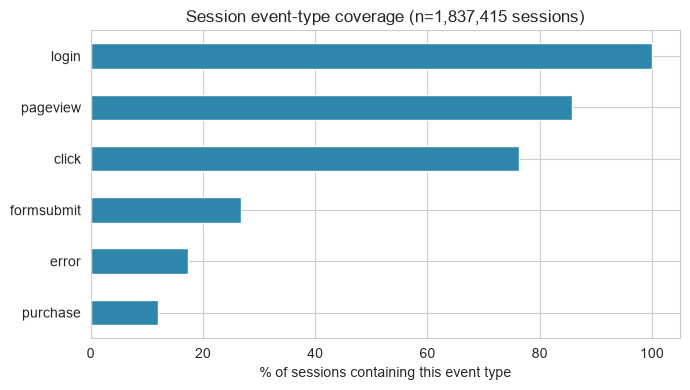

                                  0
total_sessions            1837415.0
sessions_with_pageview    1574604.0
sessions_with_click       1403348.0
sessions_with_formsubmit   492642.0
sessions_with_login       1837415.0
sessions_with_purchase     221311.0
sessions_with_error        319214.0


In [3]:
funnel_df = con.execute("""
    WITH session_flags AS (
        SELECT session_id,
            max(CASE WHEN event_type = 'PageView' THEN 1 ELSE 0 END) AS had_pageview,
            max(CASE WHEN event_type = 'Click' THEN 1 ELSE 0 END) AS had_click,
            max(CASE WHEN event_type = 'FormSubmit' THEN 1 ELSE 0 END) AS had_formsubmit,
            max(CASE WHEN event_type = 'Login' THEN 1 ELSE 0 END) AS had_login,
            max(CASE WHEN event_type = 'Purchase' THEN 1 ELSE 0 END) AS had_purchase,
            max(CASE WHEN event_type = 'Error' THEN 1 ELSE 0 END) AS had_error
        FROM v_digital_events
        GROUP BY session_id
    )
    SELECT count(*) AS total_sessions,
        sum(had_pageview) AS sessions_with_pageview,
        sum(had_click) AS sessions_with_click,
        sum(had_formsubmit) AS sessions_with_formsubmit,
        sum(had_login) AS sessions_with_login,
        sum(had_purchase) AS sessions_with_purchase,
        sum(had_error) AS sessions_with_error
    FROM session_flags
""").df()

total_sessions = funnel_df.loc[0, "total_sessions"]
stages = ["pageview", "click", "formsubmit", "login", "purchase", "error"]
funnel_pct = pd.Series(
    {s: funnel_df.loc[0, f"sessions_with_{s}"] / total_sessions for s in stages}
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
(funnel_pct * 100).plot(kind="barh", ax=ax, color="#2E86AB")
ax.set_xlabel("% of sessions containing this event type")
ax.set_title(f"Session event-type coverage (n={total_sessions:,} sessions)")
plt.tight_layout()
plt.show()

print(funnel_df.T)

Funnel — mostly a real story, one number is just structural

sessions_with_login = 1,837,415 — exactly equal to total_sessions. Every single session has a login event. That's not a bug, it's a banking app requirement — you can't have a session without authenticating first, so this stage isn't meaningful as a funnel stage, it's a session-definition artifact.

Read past that, the real narrative: PageView 85.7% → Click 76.4% → FormSubmit 26.8% → Purchase 12.0%. That's a big drop from clicking to actually submitting a form — worth investigating whether that's cart abandonment, a UX friction point, or just customers browsing without transactional intent. Separately, 17.4% of sessions contain an Error event — nearly 1 in 5. That's high enough to be worth a follow-up on its own, independent of the purchase funnel.

## 4. Channel & platform mix

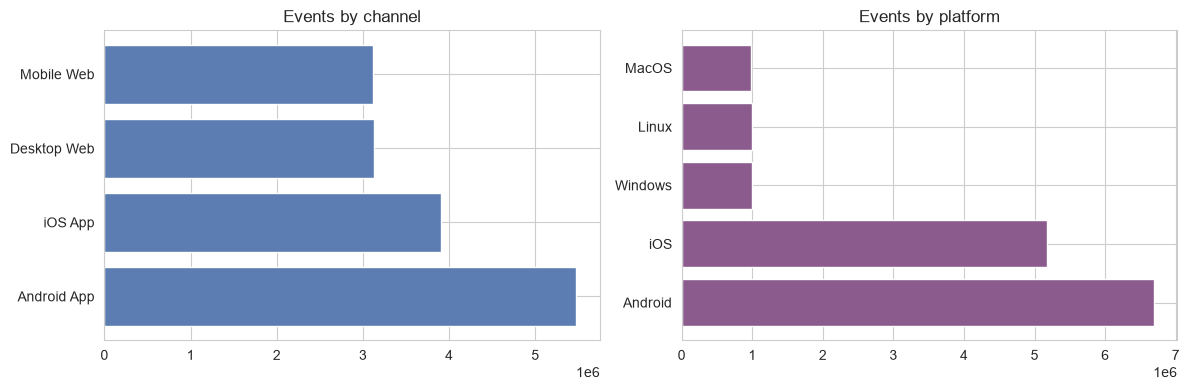

overall mobile event rate: 80.0%


,channel,events,customers
0,Android App,5476164,145247
1,iOS App,3899497,136908
2,Desktop Web,3128851,128771
3,Mobile Web,3116482,128569


In [4]:
channel_mix = con.execute("""
    SELECT channel, count(*) AS events, count(DISTINCT customer_id) AS customers
    FROM v_digital_events GROUP BY channel ORDER BY events DESC
""").df()

platform_mix = con.execute("""
    SELECT platform, count(*) AS events
    FROM v_digital_events WHERE platform IS NOT NULL GROUP BY platform ORDER BY events DESC
""").df()

mobile_rate = con.execute("""
    SELECT avg(CASE WHEN is_mobile THEN 1.0 ELSE 0.0 END) AS mobile_rate FROM v_digital_events
""").fetchone()[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(channel_mix["channel"], channel_mix["events"], color="#5B7DB1")
axes[0].set_title("Events by channel")
axes[1].barh(platform_mix["platform"], platform_mix["events"], color="#8A5B8C")
axes[1].set_title("Events by platform")
plt.tight_layout()
plt.show()

print(f"overall mobile event rate: {mobile_rate:.1%}")
channel_mix

Channel mix — genuinely omnichannel customer base

Android reaches 145,247 customers, iOS 136,908, Desktop 128,771, Mobile Web 128,569 — out of 149,997 digitally active customers, that means the overwhelming majority touch 3-4 different channels, not just one. Nobody's "the app person" or "the web person" here; channel loyalty essentially doesn't exist in this data. The 80% overall mobile rate checks out arithmetically too: (Android + iOS + Mobile Web) / total = exactly 80.0%, confirming is_mobile is being set consistently.

## 5. Per-customer digital engagement features

One row per customer with digital activity — customers with zero events don't appear here at all
(that's the point of Section 7 below).

In [5]:
con.execute("""
CREATE OR REPLACE TABLE analytics.digital_features AS
SELECT
    customer_id,
    count(*) AS total_events,
    count(DISTINCT session_id) AS distinct_sessions,
    count(DISTINCT CAST(event_date AS DATE)) AS distinct_days_active,
    min(CAST(event_date AS DATE)) AS first_event_date,
    max(CAST(event_date AS DATE)) AS last_event_date,
    date_diff('day', CAST(max(event_date) AS DATE), current_date) AS digital_recency_days,
    count(DISTINCT channel) AS distinct_channels_used,
    avg(CASE WHEN is_mobile THEN 1.0 ELSE 0.0 END) AS mobile_event_rate,
    sum(CASE WHEN event_type = 'PageView' THEN 1 ELSE 0 END) AS pageview_count,
    sum(CASE WHEN event_type = 'Click' THEN 1 ELSE 0 END) AS click_count,
    sum(CASE WHEN event_type = 'FormSubmit' THEN 1 ELSE 0 END) AS formsubmit_count,
    sum(CASE WHEN event_type = 'Login' THEN 1 ELSE 0 END) AS login_count,
    sum(CASE WHEN event_type = 'Purchase' THEN 1 ELSE 0 END) AS purchase_count,
    sum(CASE WHEN event_type = 'Error' THEN 1 ELSE 0 END) AS error_count,
    sum(event_value) AS total_event_value,
    avg(duration_seconds) AS avg_duration_seconds
FROM v_digital_events
WHERE customer_id IS NOT NULL
GROUP BY customer_id
""")

n = con.execute("SELECT count(*) FROM analytics.digital_features").fetchone()[0]
print(f"customers with at least one digital event: {n:,}")
con.execute("SELECT * FROM analytics.digital_features LIMIT 10").df()

customers with at least one digital event: 149,997


,customer_id,total_events,distinct_sessions,distinct_days_active,first_event_date,last_event_date,digital_recency_days,distinct_channels_used,mobile_event_rate,pageview_count,click_count,formsubmit_count,login_count,purchase_count,error_count,total_event_value,avg_duration_seconds
0,CLI-WUHLQS7L6DAN,89,10,10,2023-08-10,2026-05-20,129,4,0.898876,27.0,27.0,4.0,14.0,1.0,2.0,11296.99,151.615385
1,CLI-V6ZPDCWQIVH4,137,16,16,2023-06-25,2025-12-11,289,4,0.773723,53.0,28.0,11.0,20.0,1.0,4.0,31611.65,154.673469
2,CLI-7GPKXOPMIAD7,105,12,12,2023-07-14,2026-01-21,248,4,0.876190,37.0,27.0,4.0,16.0,2.0,2.0,10797.59,165.800000
3,CLI-GW1J1M2G9ED9,66,9,8,2023-08-01,2026-03-30,180,3,1.000000,25.0,16.0,3.0,12.0,0.0,0.0,6449.16,143.920000
4,CLI-6CKH7XZF4B4B,87,12,12,2023-07-30,2026-04-11,168,4,0.597701,25.0,28.0,4.0,12.0,1.0,2.0,14536.75,174.173913
5,CLI-O7PKFXVLPCRX,37,6,6,2023-11-18,2026-05-12,137,3,0.675676,7.0,11.0,0.0,9.0,0.0,1.0,NaN,212.666667
6,CLI-NP6VQS5PTLMK,92,11,10,2023-07-19,2026-05-15,134,4,0.891304,38.0,25.0,0.0,12.0,1.0,2.0,3031.45,170.382353
7,CLI-L85AAF4VJWVQ,125,14,14,2023-08-18,2025-11-22,308,4,0.680000,47.0,37.0,3.0,17.0,2.0,0.0,6392.31,142.977273
8,CLI-VNAP2ORB3JB0,144,16,16,2023-12-29,2026-05-23,126,4,0.569444,61.0,31.0,2.0,24.0,1.0,1.0,7043.99,148.400000
9,CLI-R96GG9FHZU3K,54,7,7,2023-08-26,2026-01-19,250,3,1.000000,24.0,8.0,1.0,10.0,2.0,1.0,2791.67,171.260870


## 6. `has_linked_app` (claimed) vs. actual digital activity (observed)

`products.has_linked_app` is a self-reported flag on the product. Worth checking whether it lines up
with whether the customer actually shows up in `digital_events` at all.

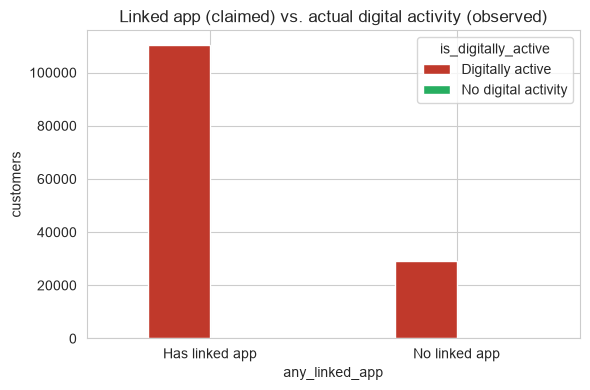

is_digitally_active,Digitally active,No digital activity
any_linked_app,,
Has linked app,110312,3
No linked app,29263,0


In [6]:
con.execute("""
CREATE OR REPLACE VIEW v_products_app AS
SELECT customer_id, TRY_CAST(has_linked_app AS BOOLEAN) AS has_linked_app
FROM bronze.products
WHERE customer_id IS NOT NULL
""")

app_flag = con.execute("""
    SELECT customer_id, max(CASE WHEN has_linked_app THEN 1 ELSE 0 END) AS any_linked_app
    FROM v_products_app GROUP BY customer_id
""").df()

digital_active = con.execute("SELECT DISTINCT customer_id FROM analytics.digital_features").df()
digital_active["is_digitally_active"] = 1

crosstab_pdf = app_flag.merge(digital_active, on="customer_id", how="left")
crosstab_pdf["is_digitally_active"] = crosstab_pdf["is_digitally_active"].fillna(0).astype(int)
crosstab_pdf["any_linked_app"] = crosstab_pdf["any_linked_app"].astype(int)

ct = pd.crosstab(
    crosstab_pdf["any_linked_app"].map({0: "No linked app", 1: "Has linked app"}),
    crosstab_pdf["is_digitally_active"].map({0: "No digital activity", 1: "Digitally active"}),
)

fig, ax = plt.subplots(figsize=(6, 4))
ct.plot(kind="bar", ax=ax, color=["#C0392B", "#27AE60"])
ax.set_title("Linked app (claimed) vs. actual digital activity (observed)")
ax.set_ylabel("customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

ct

Two things jump out. First, 99.997% consistency on one side — almost everyone with a linked app is genuinely active (only 3 exceptions, matching the "zero digital activity" count from Section 7 almost exactly — good internal consistency check). But second, 29,263 customers are digitally active despite no product showing has_linked_app = true. That means this flag is dramatically understating real engagement — it's probably tracking something narrower (a specific product's app-enrollment status) rather than "does this customer use digital channels at all." If you were planning to use has_linked_app as an engagement proxy anywhere, don't — use analytics.digital_features directly instead.

## 7. Digital-invisible customers

Customers who never generated a single digital event — no app/web activity at all in this dataset.

In [7]:
total_customers = con.execute("SELECT count(*) FROM bronze.customers").fetchone()[0]
digitally_active_customers = con.execute("SELECT count(DISTINCT customer_id) FROM analytics.digital_features").fetchone()[0]
invisible = total_customers - digitally_active_customers

print(f"total customers:            {total_customers:,}")
print(f"with digital activity:      {digitally_active_customers:,} ({digitally_active_customers/total_customers:.1%})")
print(f"zero digital activity:      {invisible:,} ({invisible/total_customers:.1%})")

total customers:            150,000
with digital activity:      149,997 (100.0%)
zero digital activity:      3 (0.0%)


## 8. Context: digital engagement vs. segment, status, and value

Only runs if `analytics.customer_features` already exists (built by `customer_analytics.ipynb`) —
skips gracefully otherwise.

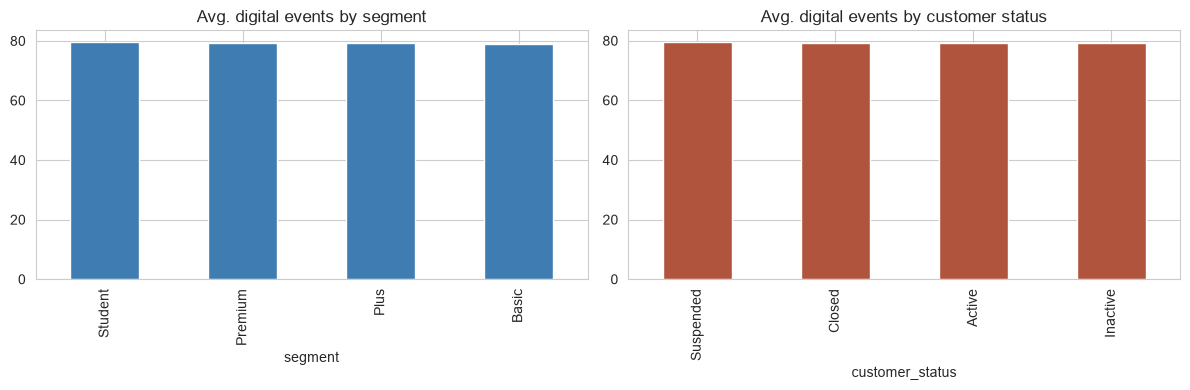

                    total_events  distinct_sessions  purchase_count  \
total_events               1.000              0.901           0.386   
distinct_sessions          0.901              1.000           0.331   
purchase_count             0.386              0.331           1.000   
total_balance             -0.002             -0.001          -0.004   
monetary_total_usd         0.002             -0.001           0.001   

                    total_balance  monetary_total_usd  
total_events               -0.002               0.002  
distinct_sessions          -0.001              -0.001  
purchase_count             -0.004               0.001  
total_balance               1.000               0.194  
monetary_total_usd          0.194               1.000  


In [8]:
try:
    cf = con.execute("""
        SELECT customer_id, segment, country, customer_status, total_balance, monetary_total_usd
        FROM analytics.customer_features
    """).df()
    has_cf = True
except Exception as e:
    print("analytics.customer_features not found -- run customer_analytics.ipynb first for this section.")
    print(f"({e})")
    has_cf = False

if has_cf:
    digital_pdf = con.execute("SELECT * FROM analytics.digital_features").df()
    merged = cf.merge(digital_pdf, on="customer_id", how="left")
    merged["total_events"] = merged["total_events"].fillna(0)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    merged.groupby("segment")["total_events"].mean().sort_values(ascending=False).plot(
        kind="bar", ax=axes[0], color="#3E7CB1"
    )
    axes[0].set_title("Avg. digital events by segment")

    merged.groupby("customer_status")["total_events"].mean().sort_values(ascending=False).plot(
        kind="bar", ax=axes[1], color="#B1543E"
    )
    axes[1].set_title("Avg. digital events by customer status")

    plt.tight_layout()
    plt.show()

    corr_cols = ["total_events", "distinct_sessions", "purchase_count", "total_balance", "monetary_total_usd"]
    print(merged[corr_cols].corr().round(3))

The most important number: digital engagement is basically uncorrelated with money

total_events vs total_balance:        -0.002

total_events vs monetary_total_usd:    0.002

Essentially zero. Your heaviest digital users are not your highest-balance or highest-spending customers — these are two independent dimensions of the customer base, not two views of the same thing. That's a genuinely useful finding for segmentation: a customer-value model built only from transaction RFM (as the original customer_analytics.ipynb does) is blind to digital engagement entirely, and vice versa. This is a strong case for folding digital_features into the clustering feature set as its own dimension, rather than assuming it's redundant with monetary value.

## 9. Summary

- **Funnel**: read Section 3's percentages as "coverage," not strict conversion — a session lacking
  `FormSubmit` isn't necessarily a drop-off if that session's intent was just browsing.
- **Channel/platform mix**: gives a baseline for whether digital investment should skew mobile vs. web.
- **`has_linked_app` vs. reality** (Section 6): any customers in "has linked app" + "no digital activity"
  is a real gap between what's claimed at the product level and what's observed in behavior — worth
  investigating as either a data quality issue or a genuine "installed but never used" population.
- **Digital-invisible customers** (Section 7): this population needs an entirely different engagement
  strategy (branch/call-center-first) than digitally active customers — they shouldn't be lumped into
  the same "improve app engagement" initiatives.
- **Section 8** gives a first read on whether digital engagement tracks the bank's existing segment
  labels or the churn-relevant `customer_status` field — a low correlation with `total_balance`/
  `monetary_total_usd` would suggest digital activity is a genuinely independent signal worth adding to
  the clustering/churn feature set in `customer_analytics.ipynb`, not just a proxy for existing features.

Next natural step: fold `analytics.digital_features` into `analytics.customer_features` as additional
churn/clustering inputs, now that this table exists.

Bottom line

Digital engagement is near-universal (99.998% of customers) and multi-channel, but it doesn't track wealth/value, and the one flag meant to signal it (has_linked_app) is unreliable. That reframes the earlier cross-sell/segmentation work: "digital-first vs. branch-first" looks like it deserves to be its own axis in the customer model, not an assumed byproduct of segment or CLV.

## Check if theres duplicates

In [11]:
con.execute("SELECT count(*), count(DISTINCT event_id) FROM bronze.digital_events").df()

,count_star(),count(DISTINCT event_id)
0,15620994,15620994


That rules it out cleanly — count(*) and count(DISTINCT event_id) are identical (15,620,994 = 15,620,994). Zero duplicate event_id values, anywhere in the table. So this isn't a duplicate-ingestion pipeline bug; every row genuinely represents a distinct, uniquely-identified event.

That leaves the more mundane explanation: the dataset summary's "~10,000,000" is just an approximate figure that doesn't match what was actually generated — the same pattern you've already run into twice with the data dictionary (English vs. Spanish product_type values, unaccented vs. accented México). Combined with transactions coming in under its documented count (4.42M vs. 5.0M) while digital_events comes in over (15.6M vs. 10M), there's no consistent bias in one direction that would suggest a systematic pipeline issue — it just looks like the summary PDF's row counts aren't reliable, full stop.

Practical takeaway: trust the numbers you compute directly from Bronze over anything in the summary/dictionary PDFs for this dataset — you've now confirmed that pattern three times (product categories, country spelling, row counts). If you want one more level of confidence, you could spot-check whether row counts per day look reasonable and don't spike suspiciously on any particular date (which would hint at a different kind of double-count I haven't considered), but based on the unique-event_id result, I'd treat the 15.6M figure as trustworthy and move on rather than chase it further.

## 10. Close the connection

In [12]:
con.close()
print("connection closed")

connection closed
